In [1]:
!pip uninstall -y tensorflow
!uv pip install --no-deps --system --no-index --find-links='/kaggle/input/hengck23-submit-physionet/hengck23-submit-physionet/setup' 'connected-components-3d'

Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0
Using Python 3.11.13 environment at: /usr
Resolved 1 package in 35ms
Prepared 1 package in 128ms
Installed 1 package in 9ms
 + connected-components-3d==3.26.1


In [2]:
%%writefile constant.py

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

import kagglehub
seed = 0
CUDA0 = "cuda:0"
deterministic = kagglehub.package_import('wasupandceacar/deterministic').deterministic
deterministic.init_all(seed, disable_list=['cuda_block'])

import sys
sys.path.append('/kaggle/input/hengck23-submit-physionet/hengck23-submit-physionet')

import os
import traceback
from pathlib import Path
from shutil import copyfile
import torch
import cv2
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

if_submit = os.getenv('KAGGLE_IS_COMPETITION_RERUN')

if if_submit:
    test_meta = Path("/kaggle/input/physionet-ecg-image-digitization/test.csv")
    test_dir = Path("/kaggle/input/physionet-ecg-image-digitization/test")
else:
    test_meta = Path("/kaggle/input/physio-test-fake-dataset/test_fake/test.csv")
    test_dir = Path("/kaggle/input/physio-test-fake-dataset/test_fake")

valid_df = pd.read_csv(test_meta)
valid_df['id'] = valid_df['id'].astype(str) 
valid_id = valid_df['id'].unique().tolist()

FLOAT_TYPE = torch.float32

global_dict = {
    "stage0_dir": "/kaggle/working/stage0",
    "stage1_dir": "/kaggle/working/stage1",
    "stage2_dir": "/kaggle/working/stage2",
}

Writing constant.py


In [ ]:
%%writefile stage0.py
from constant import *
from stage0_model import Net as Stage0Net
from stage0_common import *
import torch.nn.functional as F

def apply_grayscale_guidance(image_rgb):
    """
    Advanced preprocessing to improve model inputs:
    1. Convert to grayscale.
    2. Denoise to preserve lines.
    3. Adaptive contrast enhancement (CLAHE).
    """
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    
    denoised = cv2.fastNlMeansDenoising(gray, h=10)
    
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    contrast_enhanced = clahe.apply(denoised)
    
    guidance_img = cv2.cvtColor(contrast_enhanced, cv2.COLOR_GRAY2RGB)
    
    return guidance_img

def to_device(batch, device):
    """Move dictionary to device (GPU) safely"""
    if isinstance(batch, dict):
        return {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
    return batch.to(device)

stage0_dir = Path(global_dict["stage0_dir"])
stage0_dir.mkdir(exist_ok=True, parents=True)

print("Loading Stage 0 Model...")
stage0_net = Stage0Net(pretrained=False)
stage0_net = load_net(stage0_net, '/kaggle/input/hengck23-submit-physionet/hengck23-submit-physionet/weight/stage0-last.checkpoint.pth')
stage0_net.to(CUDA0)
stage0_net.eval()

print("Starting Stage 0 Processing...")
for n, sample_id in enumerate(tqdm(valid_id)):
    path = test_dir / f'{sample_id}.png'
    output_path = stage0_dir / f'{sample_id}.png'
    
    image_original = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_original is None: 
        continue
    image_original = cv2.cvtColor(image_original, cv2.COLOR_BGR2RGB)
    
    image_for_model = apply_grayscale_guidance(image_original)
    
    batch = image_to_batch(image_for_model)
    batch = to_device(batch, CUDA0) 

    try:
        with torch.no_grad(), torch.amp.autocast('cuda', dtype=FLOAT_TYPE):
            output = stage0_net(batch)
            
        rotated, keypoint = output_to_predict(image_original, batch, output)
        
        normalised, _, _ = normalise_by_homography(rotated, keypoint)
        
        cv2.imwrite(str(output_path), cv2.cvtColor(normalised, cv2.COLOR_RGB2BGR))
        
    except Exception as e:
        copyfile(path, output_path)

print(f"Stage 0 finished. Images saved to {stage0_dir}")


Writing stage0.py


In [ ]:
%%writefile stage1.py

from constant import *
from stage1_model import Net as Stage1Net
from stage1_common import *

stage0_dir = Path(global_dict["stage0_dir"])
stage1_dir = Path(global_dict["stage1_dir"])
stage1_dir.mkdir(exist_ok=True, parents=True)

stage1_net = Stage1Net(pretrained=False)
stage1_net = load_net(stage1_net, '/kaggle/input/hengck23-submit-physionet/hengck23-submit-physionet/weight/stage1-last.checkpoint.pth')
stage1_net.to(CUDA0)
stage1_net.eval()

for n, sample_id in enumerate(tqdm(valid_id)):
    path = stage0_dir / f'{sample_id}.png'
    output_path = stage1_dir / f'{sample_id}.png'
    
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None: 
        image = cv2.imread(str(test_dir / f'{sample_id}.png'), cv2.IMREAD_COLOR)
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    batch = {'image': torch.from_numpy(np.ascontiguousarray(image.transpose(2, 0, 1))).unsqueeze(0).to(CUDA0)}

    try:
        with torch.no_grad(), torch.amp.autocast('cuda', dtype=FLOAT_TYPE):
            output = stage1_net(batch)
        gridpoint_xy, _ = output_to_predict(image, batch, output)
        rectified = rectify_image(image, gridpoint_xy)
        cv2.imwrite(str(output_path), cv2.cvtColor(rectified, cv2.COLOR_RGB2BGR))
    except Exception as e:
        copyfile(path, output_path)


Writing stage1.py


In [5]:
%%writefile stage2.py

from constant import *
import torchvision.transforms as T
from stage2_model import *
from stage2_common import *
from scipy.signal import savgol_filter

class Net3(nn.Module):
    def __init__(self, pretrained=True):
        super(Net3, self).__init__()
        encoder_dim = [64, 128, 256, 512]
        decoder_dim = [128, 64, 32, 16]
        self.encoder = timm.create_model('resnet34.a3_in1k', pretrained=pretrained, in_chans=3, num_classes=0, global_pool='')
        self.decoder = MyCoordUnetDecoder(in_channel=encoder_dim[-1], skip_channel=encoder_dim[:-1][::-1] + [0], out_channel=decoder_dim, scale=[2, 2, 2, 2])
        self.pixel = nn.Conv2d(decoder_dim[-1], 4, 1)

    def forward(self, image):
        encode = encode_with_resnet(self.encoder, image)
        last, _ = self.decoder(feature=encode[-1], skip=encode[:-1][::-1] + [None])
        pixel = self.pixel(last)
        return pixel

stage1_dir = Path(global_dict["stage1_dir"])
stage2_dir = Path(global_dict["stage2_dir"])
stage2_dir.mkdir(exist_ok=True, parents=True)

stage2_net = Net3(pretrained=False).to(CUDA0)
model_path = "/kaggle/input/physio-seg-public/pytorch/net3_009_4200/1/iter_0004200.pt"
stage2_net.load_state_dict(torch.load(model_path))
stage2_net.eval()

resize = T.Resize((1696, 4352), interpolation=T.InterpolationMode.BILINEAR)
mv_to_pixel = 78.5
zero_mv = [703.5, 987.5, 1271.5, 1531.5]
t0, t1 = 235, 4161

for n, sample_id in enumerate(tqdm(valid_id)):
    path = stage1_dir / f'{sample_id}.png'
    output_path = stage2_dir / f'{sample_id}.npy'
    
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        series = np.zeros((4, 5000)) 
        np.save(output_path, series)
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    length = valid_df[(valid_df['id']==sample_id) & (valid_df['lead']=='II')].iloc[0].number_of_rows
    
    img_input = (image[:1696, :2176] / 255.0)
    batch = resize(torch.from_numpy(np.ascontiguousarray(img_input.transpose(2, 0, 1))).unsqueeze(0)).float().to(CUDA0)
    
    try:
        with torch.no_grad(), torch.amp.autocast('cuda', dtype=FLOAT_TYPE):
            output = stage2_net(batch)
        pixel = torch.sigmoid(output).float().data.cpu().numpy()[0]
        series_in_pixel = pixel_to_series(pixel[..., t0:t1], zero_mv, length)
        series = (np.array(zero_mv).reshape(4, 1) - series_in_pixel) / mv_to_pixel
        for i in range(series.shape[0]):
            series[i] = savgol_filter(series[i], window_length=7, polyorder=2)
        np.save(output_path, series)
    except:
        np.save(output_path, np.zeros((4, length)))

Writing stage2.py


In [6]:
!python stage0.py
!python stage1.py
!python stage2.py

THIS_DIR: /kaggle/input/hengck23-submit-physionet/hengck23-submit-physionet
REF_PT: (9, 2)
Loading Stage 0 Model...
<All keys matched successfully>
Starting Stage 0 Processing...
100%|█████████████████████████████████████████████| 9/9 [00:48<00:00,  5.42s/it]
Stage 0 finished. Images saved to /kaggle/working/stage0
/kaggle/input/hengck23-submit-physionet/hengck23-submit-physionet
<All keys matched successfully>
100%|█████████████████████████████████████████████| 9/9 [00:19<00:00,  2.19s/it]
/kaggle/input/hengck23-submit-physionet/hengck23-submit-physionet
100%|█████████████████████████████████████████████| 9/9 [00:12<00:00,  1.39s/it]


📊 Analyzing file: 7663343-0011.npy


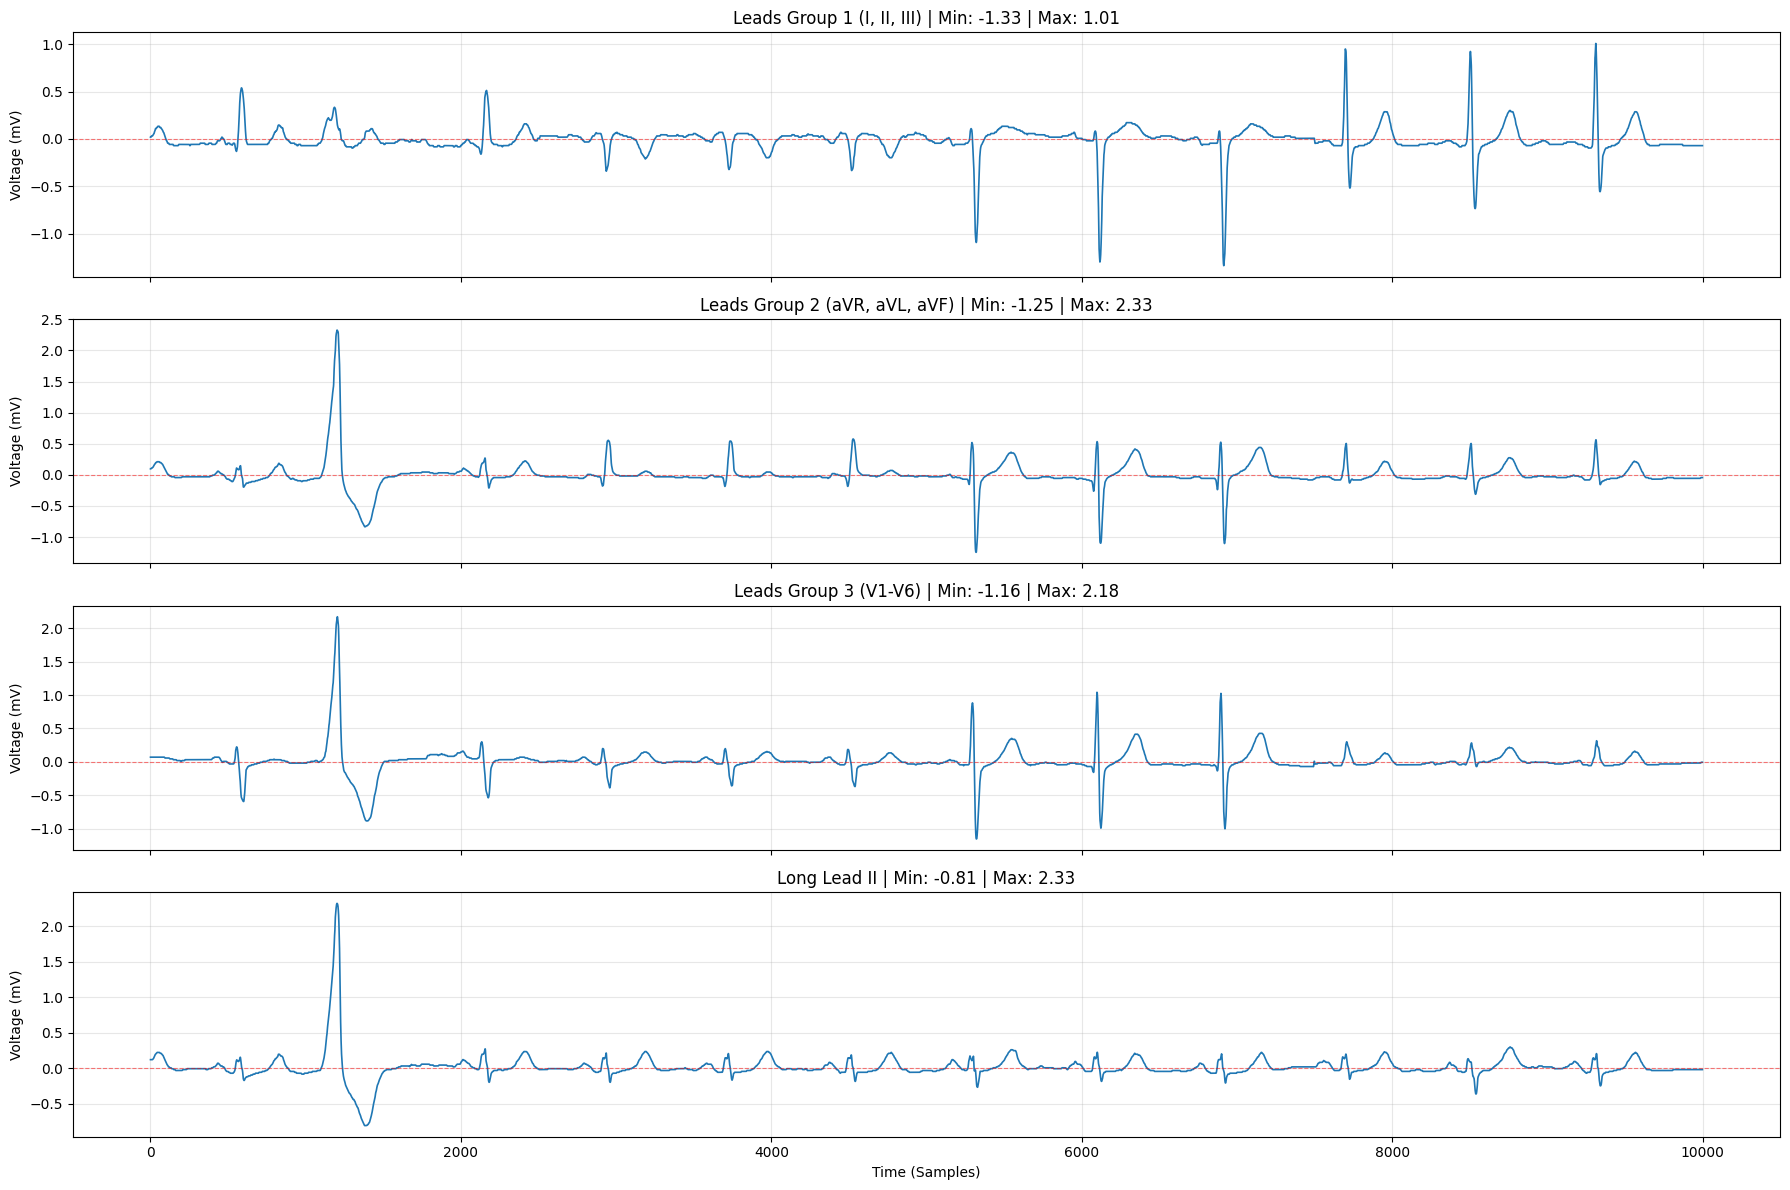

✅ Done plotting.


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random

stage2_dir = Path("/kaggle/working/stage2")
files = list(stage2_dir.glob("*.npy"))

if len(files) > 0:
    
    sample_file = random.choice(files)
    
    print(f"📊 Analyzing file: {sample_file.name}")
    
    
    series = np.load(sample_file)
    
    fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)
    lead_names = ["Leads Group 1 (I, II, III)", "Leads Group 2 (aVR, aVL, aVF)", "Leads Group 3 (V1-V6)", "Long Lead II"]
    
    for i in range(4):
        ax = axes[i]
        signal = series[i, :]
        
        ax.plot(signal, color='#1f77b4', linewidth=1.2)
        ax.set_title(f"{lead_names[i]} | Min: {signal.min():.2f} | Max: {signal.max():.2f}", fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.set_ylabel("Voltage (mV)")
        
        ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=0.8)

    plt.xlabel("Time (Samples)")
    plt.tight_layout()
    plt.show()
    
    print("✅ Done plotting.")
else:
    print("❌ No output files found in stage2!")

In [8]:
from constant import *
import gc
from scipy.signal import resample
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path

def expand_4_to_12(pred4):
    pred12 = np.zeros((pred4.shape[0], 12))
    quat = pred4.shape[0] // 4

    pred12[:quat, 0] = pred4[:quat, 0]
    pred12[:, 1] = pred4[:, 3]
    pred12[:quat, 2] = pred4[:quat, 2]
    pred12[quat:2*quat, 3] = pred4[quat:2*quat, 0]
    pred12[quat:2*quat, 4] = pred4[quat:2*quat, 1]
    pred12[quat:2*quat, 5] = pred4[quat:2*quat, 2]
    pred12[2*quat:3*quat, 6] = pred4[2*quat:3*quat, 0]
    pred12[2*quat:3*quat, 7] = pred4[2*quat:3*quat, 1]
    pred12[2*quat:3*quat, 8] = pred4[2*quat:3*quat, 2]
    pred12[3*quat:4*quat, 9] = pred4[3*quat:4*quat, 0]
    pred12[3*quat:4*quat, 10] = pred4[3*quat:4*quat, 1]
    pred12[3*quat:4*quat, 11] = pred4[3*quat:4*quat, 2]
    
    return pred12

def series_dict(series):
    series_by_lead = dict()
    for l in range(3):
        lead_names = [
            ['I',   'aVR', 'V1', 'V4'],
            ['II',  'aVL', 'V2', 'V5'],
            ['III', 'aVF', 'V3', 'V6'],
        ][l]
        split = np.array_split(series[l], 4)
        for (k, s) in zip(lead_names, split):
            series_by_lead[k] = s
    series_by_lead['II'] = series[3]
    return series_by_lead


stage2_dir = Path(global_dict["stage2_dir"])

submit_df = list()
gb = valid_df.groupby('id')

show = True

print("Generating submission file...")

for rec_idx, (sample_id, df) in enumerate(tqdm(gb)):
    try:
        
        series = np.load(stage2_dir / f'{sample_id}.npy')
        
        series_by_lead = series_dict(series)

        for _, d in df.iterrows():
            s = series_by_lead.get(d.lead, np.zeros(d.number_of_rows))
            
            if len(s) != d.number_of_rows:
                x_old = np.linspace(0, 1, len(s))
                x_new = np.linspace(0, 1, d.number_of_rows)
                s = np.interp(x_new, x_old, s)
            
            row_id = [f'{sample_id}_{t}_{d.lead}' for t in range(d.number_of_rows)]
            submit_df.append(pd.DataFrame({'id': row_id, 'value': s}))
            
    except Exception as e:
        pass

    if rec_idx % 100 == 0:
        gc.collect()

if submit_df:
    final_df = pd.concat(submit_df, axis=0, ignore_index=True)
    final_df.to_csv('submission.csv', index=False)
    print(f"✅ Done! Saved submission.csv with shape: {final_df.shape}")
    print(final_df.head())
else:
    print("❌ Error: No predictions were generated!")

Generating submission file...


100%|██████████| 9/9 [00:01<00:00,  5.72it/s]


✅ Done! Saved submission.csv with shape: (337500, 2)
                 id     value
0  7663343-0001_0_I  0.005370
1  7663343-0001_1_I  0.008931
2  7663343-0001_2_I  0.012874
3  7663343-0001_3_I  0.017199
4  7663343-0001_4_I  0.022951


In [9]:
sub = pd.read_csv('submission.csv')
print(len(sub))
sub.head(30)

337500


,id,value
0,7663343-0001_0_I,0.005370
1,7663343-0001_1_I,0.008931
2,7663343-0001_2_I,0.012874
3,7663343-0001_3_I,0.017199
4,7663343-0001_4_I,0.022951
5,7663343-0001_5_I,0.027525
6,7663343-0001_6_I,0.030639
7,7663343-0001_7_I,0.032117
8,7663343-0001_8_I,0.032260
9,7663343-0001_9_I,0.031847
